## 목표
- 시나리오  
    B사는 소비자 금융 서비스 산업에 종사하며, 특히 신용카드 서비스를 제공하고 있습니다.
    데이터 분석팀은 최근 소비자 신용카드 포트폴리오에서 수집된 방대한 고객 정보를 활용하려 합니다.
    분석팀의 목표는 고객 이탈을 예측하는 것으로, 이를 통해 서비스 개선 및 고객 충성도 향상에 필요한 조치를 취하고자 합니다.
    이들이 활용하려는 데이터에는 나이, 성별, 결혼 상태, 소득 카테고리와 같은 고객의 인구통계학적 세부사항이 포함됩니다.
    더 나아가, 신용카드 유형, 가입 기간, 비활성 기간 등 신용카드 제공 업체와의 관계에 대한 인사이트를 제공하는 데이터도 포함되어 있습니다.
    특히, 고객의 소비 행동, 총 거래 잔액, 신용 한도와 같은 중요한 데이터는 고객의 이탈 여부에 중요한 역할을 합니다.

    데이터 분석팀은 이를 통해 고객의 이탈을 예측하고,
    이러한 예측 정보를 활용하여 포트폴리오 관리 전략을 조정하거나 개별 고객에게 더 맞춤화된 서비스를 제공할 방안을 모색할 예정입니다.

        - 이탈고객 탐지가 왜 중요한지?  
        신규 고객 확보보다 기존 고객 유지 비용이 더 저렴  
        이탈 고객 예측을 통해 프로모션, 할인, 맞춤형 콘텐츠 제공 가능  
        투자자나 경영진에게 서비스 건강 지표로 보고됨  



- 신용카드 사용 고객 데이터를 활용하여 충성고객과 이탈자를 분류해보자(이진분류)
- 어떤 특성이 이탈가능고객을 탐지하는데 영향을 미쳤을지 확인해보자(데이터 탐색)

In [14]:
# Google Colab 환경에서 작업 시에만 사용
# 데이터를 불러오기 위한 환경 세팅
# - 드라이브 연동
# - 절대경로 > 상대경로 사용가능하도록 작업환경을 변경
# %cd "/content/drive/MyDrive/Colab Notebooks/Machine_Learning"

In [15]:
# Google Colab 환경에서 작업 시에만 사용
# from google.colab import drive
# 작업 환경 확인
# %pwd

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1.데이터 로딩
- data폴더에접근해서 데이터불러온 후 data 변수에 담아주기

In [17]:
# 판다스 데이터 프레임 옵션 설정
# 컬럼 최대 개수 제한되어 있음
# 30개 정도 출력하도록 변경해보자!
pd.set_option("display.max_columns", None) # 제한없음
pd.set_option("display.max_columns", 30) # 최대 30개 컬럼까지 출력


In [18]:
data = pd.read_csv("data/BankChurners.csv")
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [19]:
# desc
data_desc = pd.read_csv("data/BankChurners_DESC.csv")
data_desc

# 고객 이탈(churn) : 일정 기간 안에 서비스를 그만 쓰거나 결제/구독을 해지한 사용자를 부름
# 반대 개념: retained customer(잔존 고객) 또는 retention(유지율)


,Column,Description
0,CLIENTNUM,고객별 고유 식별 번호
1,Attrition_Flag,고객 이탈 여부를 나타내는 지표
2,Customer_Age,고객의 나이
3,Gender,고객의 성별
4,Dependent_count,고객이 경제적으로 부양하는 가족의 수
5,Education_Level,고객의 교육 수준
6,Marital_Status,고객의 결혼 상태
7,Income_Category,고객의 연간 소득 범위를 나타내는 카테고리
8,Card_Category,고객이 소지한 신용카드의 유형
9,Months_on_book,계좌를 유지한 기간


In [20]:
# 데이터 크기
data.shape

# 약 1만건에 대한 고객 정보
# 고객의 활동을 설명하기 위한 고객 정보 컬럼 21개

(10127, 21)

In [21]:
data.info()

# 행, 열
# 결측치 여부 (NaN) : 없음
# 데이터 타입: int, object
#  0   CLIENTNUM                 10127 non-null  int64
#  1   Attrition_Flag            10127 non-null  object => 종속변수
#  2   Customer_Age              10127 non-null  int64
#  3   Gender                    10127 non-null  object
#  4   Dependent_count           10127 non-null  int64
#  5   Education_Level           10127 non-null  object
#  6   Marital_Status            10127 non-null  object
#  7   Income_Category           10127 non-null  object
# 인구통계학적 측면 데이터


#  8   Card_Category             10127 non-null  object
#  9   Months_on_book            10127 non-null  int64
#  10  Total_Relationship_Count  10127 non-null  int64
#  11  Months_Inactive_12_mon    10127 non-null  int64
#  12  Contacts_Count_12_mon     10127 non-null  int64
#  13  Credit_Limit              10127 non-null  float64
#  14  Total_Revolving_Bal       10127 non-null  int64
#  15  Avg_Open_To_Buy           10127 non-null  float64
#  16  Total_Amt_Chng_Q4_Q1      10127 non-null  float64
#  17  Total_Trans_Amt           10127 non-null  int64
#  18  Total_Trans_Ct            10127 non-null  int64
#  19  Total_Ct_Chng_Q4_Q1       10127 non-null  float64
#  20  Avg_Utilization_Ratio     10127 non-null  float64
# 카드사 고객으로써 활동한 데이터(고객 행동 데이터)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

# 2.데이터 전처리 및 탐색
- 이탈율 구해보기

In [22]:
# 전체 이용 고객 수 대비 이탈자의 비율 확인
data.shape[0]

10127

In [23]:
data["Attrition_Flag"].value_counts()
# 이탈 비율 구하기
print("-고객 이탈율: ", f"{1627/(8500 + 1627)*100:.2f} %")

-고객 이탈율:  16.07 %


## 2.1.Deep Dive Analysis: 어떤 특성의 고객이 많이 이탈하는가?
다양한 측면에서 분석해보자

In [24]:
data["Attrition_Flag"].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [25]:
# 탑 데이터를 수치화 진행해보기
# -분석 용이하게
data["churn"] = data["Attrition_Flag"].map({"Existing Customer":0, "Attrited Customer" : 1})
data["churn"].value_counts() # 수치형으로 변형됐고, 의미는 여전히 동일

churn
0    8500
1    1627
Name: count, dtype: int64

## 2.2.인구 통계학 측면 - 성별/교육 수준/결혼 상태/연간 소득/연령대별 이탈의 간계  
- 3   Gender                    10127 non-null  object
- 5   Education_Level           10127 non-null  object
- 7   Income_Category           10127 non-null  object



In [26]:
data_desc["Column"].values

array(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype=object)

In [27]:
data["Gender"].value_counts()
data["Education_Level"].value_counts()
data["Marital_Status"].value_counts()
data["Income_Category"].value_counts()


# 가설 : 학업수준이 낮을 수록 이탈율이 높을 것이다.!
# 검증: 예시) 학업수준이 낮을수록 이탈율이 상당히 높음을 알 수 있다. => 해당 가설은 성립되지 않는다. 오히려 학업수준이 높을 수록 이탈율이 높음을 알 수 있다.

# count 해당 교육수준에 대한 0,1 카테고리값을 가진 모든 사람의 수
# sum 해당 교육수준에 대한 카테고리값을 가진 사람의 수
data.groupby(by = "Education_Level")["churn"].agg(["count", "sum"])

# 변수에 담아주자
temp = data.groupby(by = "Education_Level")["churn"].agg(["count", "sum"])
# 소수점 제거하고 보기 round
round(temp["sum"]/temp["count"] * 100, 1)

Education_Level
College          15.2
Doctorate        21.1
Graduate         15.6
High School      15.2
Post-Graduate    17.8
Uneducated       15.9
Unknown          16.9
dtype: float64


*Gender별 이탈률


,count,sum,ratio
Gender,,,
F,5358,930,17.4
M,4769,697,14.6



*Education_Level별 이탈률


,count,sum,ratio
Education_Level,,,
College,1013,154,15.2
Doctorate,451,95,21.1
Graduate,3128,487,15.6
High School,2013,306,15.2
Post-Graduate,516,92,17.8
Uneducated,1487,237,15.9
Unknown,1519,256,16.9



*Marital_Status별 이탈률


,count,sum,ratio
Marital_Status,,,
Divorced,748,121,16.2
Married,4687,709,15.1
Single,3943,668,16.9
Unknown,749,129,17.2



*Income_Category별 이탈률


,count,sum,ratio
Income_Category,,,
$120K +,727,126,17.3
$40K - $60K,1790,271,15.1
$60K - $80K,1402,189,13.5
$80K - $120K,1535,242,15.8
Less than $40K,3561,612,17.2
Unknown,1112,187,16.8


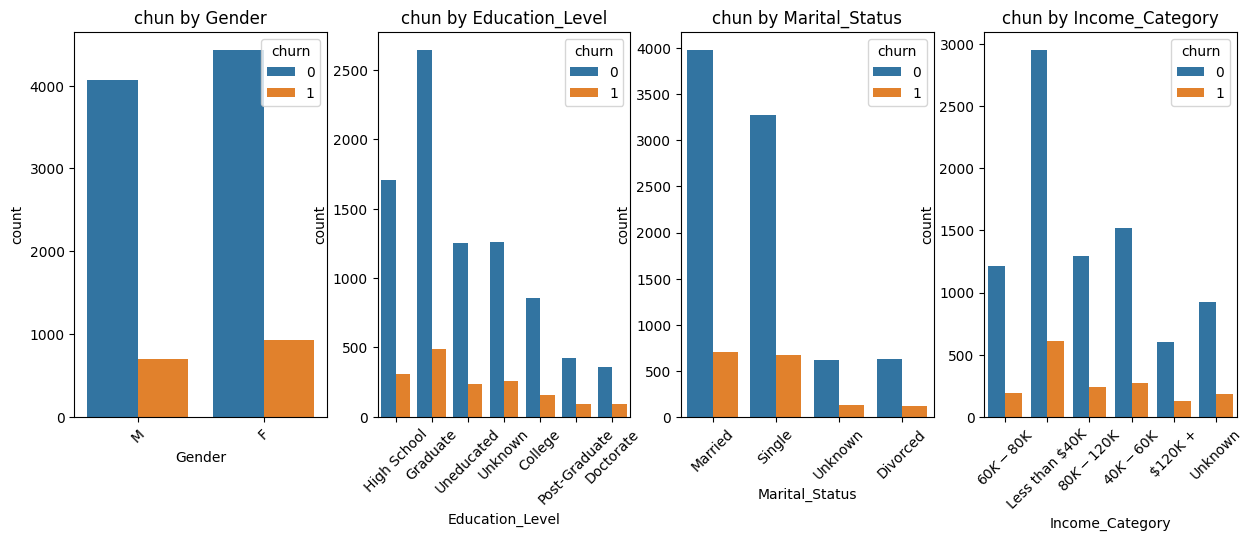

In [28]:
# 성별/교육 수준/결혼 상태/ 연간 소득별 이탈 분포
# 데이터들이 다 문자열 형태- 빈도수 카운트하는 막대그래프 연결
cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category"]
# enumerate : 반복가능한 대상을 반복시키면서 인덱스 번호를 부여하여 풀력해주는 기능
#for i in cols:
#  print(data[i])

# list(enumerate(cols))

# 격자 만들기(Frame 준비)
plt.figure(figsize=(15, 5))

# enumerate로 for문 돌리기
for i, col in enumerate(cols):
  df_gb = data.groupby(col)["churn"].agg(["count","sum"])

  # 이탈율 ratio 추가해보기
  df_gb["ratio"] = round(df_gb["sum"]/df_gb["count"] * 100, 1)
  print(f"\n*{col}별 이탈률")

  display(df_gb)

  plt.subplot(1,len(cols), i+1)
  sns.countplot(data=data, x=col, hue="churn")
  plt.title(f"chun by {col}")
  plt.xticks(rotation=45) # X축 눈금 라벨명을 45도 정도 회전

plt.show()


In [29]:
# Gender (성별) ▶ 여성 고객의 이탈율이 남성보다 높음.
# ⇒ 마케팅 및 유지 전략에서 여성 대상 이탈 방지책 강화 필요.

# Education_Level (교육 수준) ▶ 박사(Doc) 소지자의 이탈율이 가장 높음.
# ⇒ 고학력자일수록 이탈율이 높게 나타나는 경향.
# ⇒ 고학력층의 니즈 파악 및 프리미엄 서비스 개선 필요.

# Marital_Status (결혼 여부) ▶ 기혼 고객(Married)의 이탈율이 가장 낮음.
# ⇒ 비교적 안정된 생활 패턴? → 이탈 방지.

# Income_Category (소득 수준) ▶ $60K ~ $80K 구간에서 이탈율이 가장 낮음.
# ⇒ 중간소득 고객은 비교적 충성도 높음.
# ⇒ 고소득층($120K+) 및 저소득층(<$40K)의 이탈율 높음 → 각기 다른 접근 필요.

# [종합 해석]
# 이탈율이 높은 특성 조합
# -> 여성, 박사학위, 고소득or저소득, 미혼or이혼

# 이탈율이 낮은 특성 조합
# -> 남성, 고졸or대졸, 중간소득, 기혼

# 타겟(페르소나) 설정 가능해보임


* 연령대 별 이탈률
           count  sum  ratio
Age_Group                   
20-29        195   17    8.7
30-39       1841  261   14.2
40-49       4561  772   16.9
50-59       2998  506   16.9
60+          532   71   13.3


C:\Users\lgdx\AppData\Local\Temp\ipykernel_19988\1918564053.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_gp = data.groupby('Age_Group')['churn'].agg(['count','sum'])
C:\Users\lgdx\AppData\Local\Temp\ipykernel_19988\1918564053.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_gp.index, y=df_gp['ratio'], palette='YlGnBu')


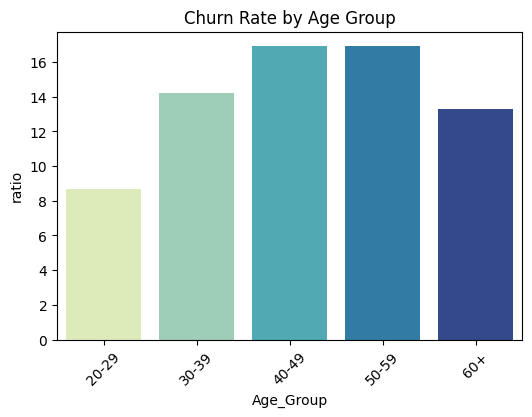

In [30]:
# 연령대 별 이탈 분포
# pd.cut() 연속적인 수치 데이터를 구간별로 cut(잘라주는) 기능 -> 범주화(구간화)
bins = [20, 30, 40, 50, 60, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60+'] # 구간에 대한 이름 설정
data['Age_Group'] = pd.cut(data['Customer_Age'], bins=bins, labels=labels, right=False)

df_gp = data.groupby('Age_Group')['churn'].agg(['count','sum'])
df_gp['ratio'] = round((df_gp['sum'] / df_gp['count']) * 100, 1)
print("\n* 연령대 별 이탈률")
print(df_gp)

plt.figure(figsize=(6, 4))
sns.barplot(x=df_gp.index, y=df_gp['ratio'], palette='YlGnBu')
plt.title("Churn Rate by Age Group")
plt.xticks(rotation=45)
plt.show()

# 연령대: 40대, 50대의 이탈률이 높은 편.

## 2.3.고객 행동 측면 - 거래 횟수, 거래 금액별 이탈의 관계

In [31]:
### 고객 행동 측면 - 거래 횟수, 거래 금액별 이탈의 관계
data_desc

,Column,Description
0,CLIENTNUM,고객별 고유 식별 번호
1,Attrition_Flag,고객 이탈 여부를 나타내는 지표
2,Customer_Age,고객의 나이
3,Gender,고객의 성별
4,Dependent_count,고객이 경제적으로 부양하는 가족의 수
5,Education_Level,고객의 교육 수준
6,Marital_Status,고객의 결혼 상태
7,Income_Category,고객의 연간 소득 범위를 나타내는 카테고리
8,Card_Category,고객이 소지한 신용카드의 유형
9,Months_on_book,계좌를 유지한 기간


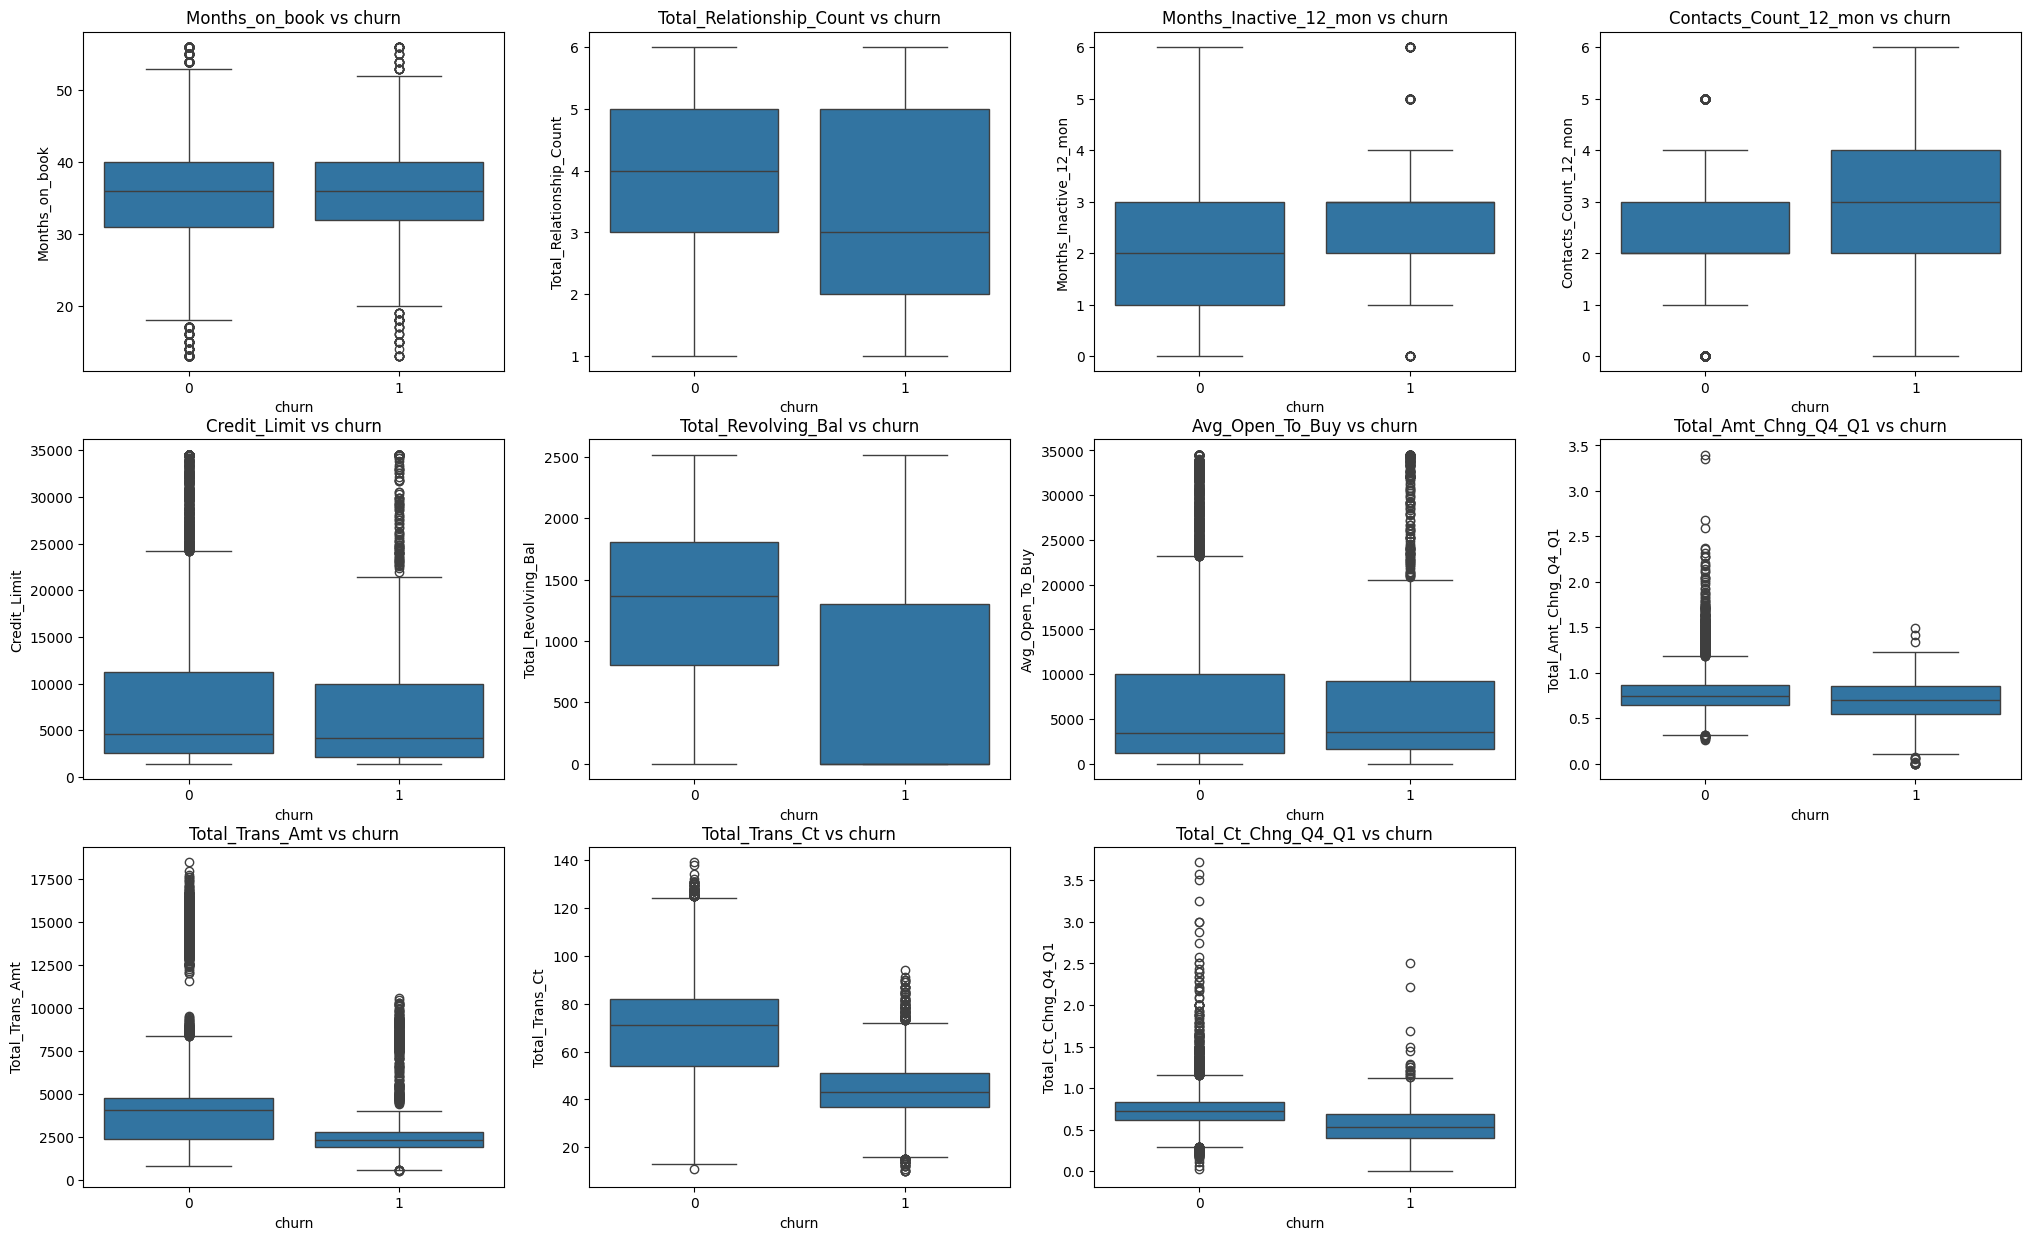

In [32]:
# 컬럼 선택
cols2 = data_desc["Column"][9:20]
cols2



plt.figure(figsize=(25, 15))
# 수치(연속형) 데이터 시각화
for i, col in enumerate(cols2):
  plt.subplot(3, 4, i+1)
  sns.boxplot(data=data, x="churn", y=col)
  plt.title(f"{col} vs churn")

plt.show()

In [33]:
# 이탈 고객의 행동 특성
# 1) 거래 활동이 전반적으로 적다
# 2) 상품 활용도가 낮다.
# 3) 연락 횟수 多 => 이탈률이 높다.
# 4) 비활성 기간이 길다.

- 이탈 결정 특성 분석 - 가장 영향을 많이 미치는 특성은 무엇일까? => 머신러닝 모델이 예측에 가장 중요하게 사용한 특성을 확인하자 (특성의 중요도)

In [34]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'churn', 'Age_Group'],
      dtype='object')

In [35]:
# 문제, 답 구분하기

data.iloc[: , 3:]

X = data.drop(["CLIENTNUM", "Attrition_Flag", "Customer_Age", "churn" ], axis = 1)
y = data.iloc[:, 1]

print(X.shape, y.shape)


(10127, 19) (10127,)


In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Gender                    10127 non-null  object  
 1   Dependent_count           10127 non-null  int64   
 2   Education_Level           10127 non-null  object  
 3   Marital_Status            10127 non-null  object  
 4   Income_Category           10127 non-null  object  
 5   Card_Category             10127 non-null  object  
 6   Months_on_book            10127 non-null  int64   
 7   Total_Relationship_Count  10127 non-null  int64   
 8   Months_Inactive_12_mon    10127 non-null  int64   
 9   Contacts_Count_12_mon     10127 non-null  int64   
 10  Credit_Limit              10127 non-null  float64 
 11  Total_Revolving_Bal       10127 non-null  int64   
 12  Avg_Open_To_Buy           10127 non-null  float64 
 13  Total_Amt_Chng_Q4_Q1      10127 non-null  floa

In [37]:
# encoding
# object 형식으로 데이터 인코딩하기
# pd.get_dummies(대상)
X_one_hot = pd.get_dummies(X)
X_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dependent_count                 10127 non-null  int64  
 1   Months_on_book                  10127 non-null  int64  
 2   Total_Relationship_Count        10127 non-null  int64  
 3   Months_Inactive_12_mon          10127 non-null  int64  
 4   Contacts_Count_12_mon           10127 non-null  int64  
 5   Credit_Limit                    10127 non-null  float64
 6   Total_Revolving_Bal             10127 non-null  int64  
 7   Avg_Open_To_Buy                 10127 non-null  float64
 8   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 9   Total_Trans_Amt                 10127 non-null  int64  
 10  Total_Trans_Ct                  10127 non-null  int64  
 11  Total_Ct_Chng_Q4_Q1             10127 non-null  float64
 12  Avg_Utilization_Ratio           

In [38]:
# train,test 분리
from sklearn.model_selection import train_test_split

# 랜덤샘플링
# X_train, X_test, y_train, y_test = train_test_split(문제, 답, 7:3, 1234, stratify = y )
X_train, X_test, y_train, y_test = train_test_split(X_one_hot, y,test_size=0.3, random_state= 1234, stratify = y )

# 크기학인
print("훈련용:", X_train.shape, y_train.shape)
print("테스트용:", X_test.shape, y_test.shape)


훈련용: (7088, 41) (7088,)
테스트용: (3039, 41) (3039,)


In [39]:
# tree 불러오기
from sklearn.tree import DecisionTreeClassifier

# 정확도 기능 불러오기
from sklearn.metrics import accuracy_score

# 모델 생성
# tree_model = DecisionTreeClassifier(과적합방지 hyperparameter)
tree_model = DecisionTreeClassifier()
# 모델 학습
tree_model.fit(X_train, y_train)

# 학습


# 예측
pred = tree_model.predict(X_test)
print(pred)


# 정확도 출력
print("-tree 정확도", accuracy_score(y_test, pred))

# accuracy_score(실제값, 예측값)

['Attrited Customer' 'Attrited Customer' 'Existing Customer' ...
 'Existing Customer' 'Existing Customer' 'Existing Customer']
-tree 정확도 0.932872655478776


In [40]:
# 모델 평가하는 기능 내부 탑재
# tree_model.score(테스트문제, 테스트답) # score: 분류 문제일 경우 정확도를 출력
tree_model.score(X_test, y_test) # score: 분류 문제일 경우 정확도를 출력
# score 연결하면 predict 과정이 생략 가능


0.932872655478776

특성의 중요도 (tree 모델이 데이터를 특성의 규칙에 맞춰 분기하는데, 어떤 특성이 가장 중요하게 여겨졌을까?)

In [41]:
# X_one_hot
X_train.columns

Index(['Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
       'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'Gender_F', 'Gender_M',
       'Education_Level_College', 'Education_Level_Doctorate',
       'Education_Level_Graduate', 'Education_Level_High School',
       'Education_Level_Post-Graduate', 'Education_Level_Uneducated',
       'Education_Level_Unknown', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Unknown', 'Income_Category_$120K +',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown', 'Card_Category_Blue', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver', 'Ag

<Axes: >

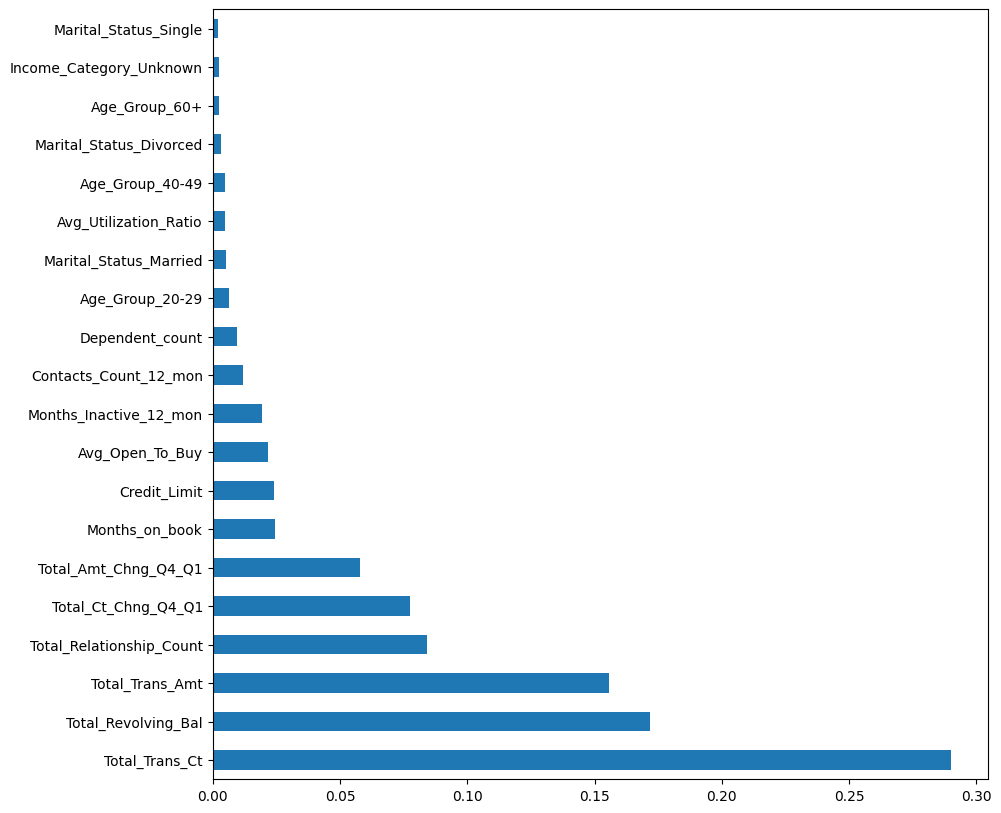

In [42]:
# 고객 이탈 탐지 -> 어떤 특성이 가장 중요했을까?
tree_model.feature_importances_

# 수치가 높을 수록 중요한 특성이다.!

# array data를 series로 변경
pd.Series(tree_model.feature_importances_, index = X_train.columns)

# 변수에 담아주기
ft_import = pd.Series(tree_model.feature_importances_, index = X_train.columns)
ft_import.sort_values(ascending = False)

# 잘라서 20개만 보기
ft_import.sort_values(ascending = False)[:20].plot(kind = "barh", figsize = (10, 10))


In [43]:
# 핵심 인사이트 도출하는 특성값
# - 고객 이탈 탐지하는 가장 영향력이 높은 특성
# 총 거래 횟수, 회전잔액, 총 거래금액